### testing ground

In [543]:
## import numpy as np
import pandas as pd
import networkx as nx
import functions_regular as fnr
import functions_subtrees as fns
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import itertools as it
import math
importlib.reload(fnr)
importlib.reload(fns)

<module 'functions_subtrees' from '/Users/mbpr/Desktop/internship/Motif discovery/motif-discovery/src/functions_subtrees.py'>

In [170]:
# enumerates all subtrees of a tree in H rooted at h
def enumSubtrees(H, h):
    combos = []
    
    if (H.node[h]['coreness'] > 1 and not H.node[h]['is_root']):
        print('h is not in 1-shell')
        return
    
    T = fns.detachTree(H, h, h)
    children = T[0][h]
    
    for i in range(len(children)):
        combos.append(it.combinations(children, i+1))
        
    return combos

In [529]:
def hencealoft(H, G):
    instances = []
    
    fns.onionDecompose(G)
    fns.onionDecompose(H)
    
    marks_G = {}
    marks_H = {}
    
    K = nx.Graph()
    K.add_edges_from(H.edges())
    
    attributesH = H.nodes[0].keys()
    for name in attributesH:
        attr = nx.get_node_attributes(H, name)
        nx.set_node_attributes(K, attr, name)

    aut = fnr.findSubgraphInstances(H, K, False)
    M = fnr.symmetryConditions(aut)
    
    for h in H:
        
        if (H.nodes[h]['coreness'] == 1 or H.nodes[h]['is_root']):
            print('h:', h)
            combos = enumSubtrees(H, h)
            print('combos:', combos)
            
            for i in combos:
                for select in i:
                    print('select:', select)
                    
                    T = fns.detachTree(H, h, h, select)
                    A = T[0]
                    B = T[1]
                    print('A:', A.nodes())
                    
                    for g in G:
                        if (G.nodes[g]['is_root']):
                            print('g:', g)
                            f = fnr.Map([(h, g)])
                            
                            S = fns.detachTree(G, g, g)
                            S = S[0]
                            print('S:', S.nodes())
                            
                            print('f before extend:', f.getMap())
                            
                            
                            N = list(A.nodes())
                            N.remove(h)
                            to_extend = [(val, list(S)[key]) for key, val in enumerate(N)]
                            f.extend(to_extend)
                            
                            for s in S:
                                if (s != g):
                                    marks_G[s] = True
                            
                            nx.set_node_attributes(G, marks_G, 'marked')
                            
                            count = fns.countRootedSubtrees(A, h, S, g)
                            print('count:', count)
                            f.setMult(count)
                            
                            print('f before isoext:', f.getMap())
                            iso = fnr.isomorphicExtensions(f, H, G, 0, M)
                            
                            if(type(iso) == type(f)):
                                instances.append(iso)
                                
                            else:
                                for i in iso:
                                    instances.append(i)
#                                     print('instances:', tuple(i.getMap()))

    for g in list(G.nodes()):
        if (G.nodes[g]['coreness'] == 1):
            G.remove_node(g)
    
    print('1-shell:', [[tuple(f.getMap()), f.getMult()] for f in instances])
    total = 0
    for f in instances:
        total = total + f.getMult()
    
    print('1-shell:', total)
    
    print('2-core:', fnr.findSubgraphInstances(H, G))
    

In [544]:
m = 1
gSize = 10
hSize = 5

H = nx.scale_free_graph(hSize, seed=m)
H = nx.to_undirected(H)
J = nx.Graph()
J.add_edges_from(H.edges())
attributesH = H.nodes[0].keys()
for name in attributesH:
    attr = nx.get_node_attributes(H, name)
    nx.set_node_attributes(J, attr, name)

G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)
K = nx.Graph()
K.add_edges_from(G.edges())
K = fns.relabelByDegree(G)
attributesG = G.nodes[0].keys()
for name in attributesG:
    attr = nx.get_node_attributes(G, name)
    nx.set_node_attributes(K, attr, name)

print('regular:', fnr.findSubgraphInstances(J, K, True))

H = nx.scale_free_graph(hSize, seed=m)
H = nx.to_undirected(H)
J = nx.Graph()
J.add_edges_from(H.edges())
attributesH = H.nodes[0].keys()
for name in attributesH:
    attr = nx.get_node_attributes(H, name)
    nx.set_node_attributes(J, attr, name)
    
G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)
K = nx.Graph()
K.add_edges_from(G.edges())
K = fns.relabelByDegree(G)
attributesG = G.nodes[0].keys()
for name in attributesG:
    attr = nx.get_node_attributes(G, name)
    nx.set_node_attributes(K, attr, name)
    
hencealoft(J, K)


{}
regular: 12
h: 0
combos: [<itertools.combinations object at 0xa1f1a44a8>]
select: (4,)
A: [4, 0]
g: 7
S: [0, 7, 2, 3, 6]
f before extend: [(0, 7)]
count: 3.0
f before isoext: [(0, 7) (4, 0)]
g: 8
S: [1, 8, 5]
f before extend: [(0, 8)]
count: 2.0
f before isoext: [(0, 8) (4, 1)]
h: 2
combos: [<itertools.combinations object at 0xa1e883868>]
select: (3,)
A: [3, 2]
g: 7
S: [0, 7, 2, 3, 6]
f before extend: [(2, 7)]
count: 3.0
f before isoext: [(2, 7) (3, 0)]
g: 8
S: [1, 8, 5]
f before extend: [(2, 8)]
count: 2.0
f before isoext: [(2, 8) (3, 1)]
h: 4
combos: []
h: 3
combos: []
1-shell: [[((0, 7), (1, 9), (2, 8), (3, 1), (4, 0)), 3.0], [((0, 7), (1, 9), (2, 8), (3, 5), (4, 0)), 3.0]]
1-shell: 6.0
2-core: 0


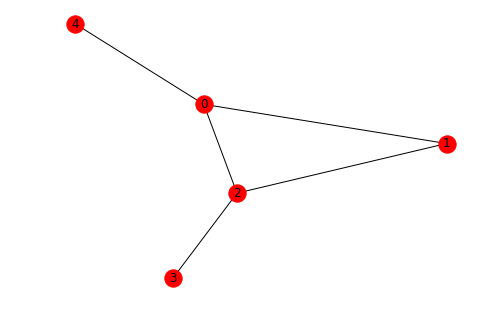

In [534]:
nx.draw(J, with_labels=True)

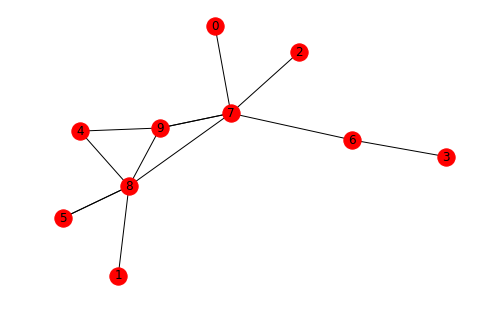

In [540]:
G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)
K = nx.Graph()
K.add_edges_from(G.edges())
K = fns.relabelByDegree(G)
attributesG = G.nodes[0].keys()
for name in attributesG:
    attr = nx.get_node_attributes(G, name)
    nx.set_node_attributes(K, attr, name)
nx.draw(K, with_labels=True)

In [ ]:
subtrees = enumSubtrees(H, 0)
for l in subtrees:
    for select in l:
        T = fns.detachTree(H, 0, 0, select)
        print('select:', select)
        print('nodes:', T.nodes())

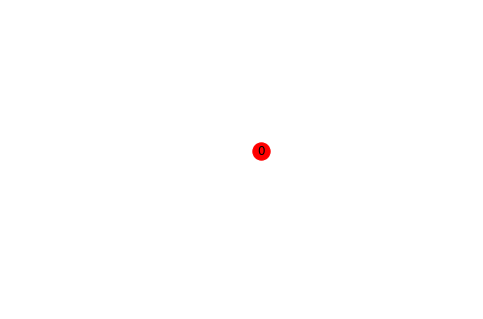

In [430]:
fns.onionDecompose(H)
T = fns.detachTree(H, 0, 0, [4, 7, 10])
nx.draw(T[0], with_labels=True)

In [ ]:
# H = parseStringToGraph('[[1,2], [2,3], [3,4], [3,5], [4,2], [4,5], [5,0]]')
# G = parseStringToGraph('[[1,2], [2,3], [3,4], [3,5], [4,2], [4,5], [5,0]]')

G = nx.scale_free_graph(gSize, seed=m)
G = nx.to_undirected(G)
K = nx.Graph()
K.add_edges_from(G.edges())

K = fns.relabelByDegree(G)

H = nx.scale_free_graph(hSize, seed=m)
H = nx.to_undirected(H)
J = nx.Graph()
J.add_edges_from(H.edges())

a = fnr.findSubgraphInstances(J, K, True)

G = nx.scale_free_graph(gSize, seed=m) #5, 7
G = nx.to_undirected(G)
K = nx.Graph()
K.add_edges_from(G.edges())
K = fns.relabelByDegree(G)

# b = fns.findSubgraphInstances(J, K, True)

# print(a, b, a==b)

In [ ]:
G = nx.scale_free_graph(gSize, seed=m) #5, 7
G = nx.to_undirected(G)
G = fns.relabelByDegree(G)
fns.onionDecompose(G)
nx.draw(G, with_labels=True)

In [ ]:
# counts the matchings between every subtree of T with S and stores
# them in the dictionary
def countSubtreeMatchings(T, rootT, parentT, S, rootS, dic):
    dic[rootT] = fns.countRootedSubtrees(T, rootT, S, rootS)
    
    if (rootT == parentT):
        children = set(T[rootT])
    else:
        children = set(T[rootT]).difference({parentT})
    
    if (children):
        for i in children:
            Ti = fns.detachTree(T, i, rootT)
            countSubtreeMatchings(Ti, i, rootT, S, rootS, dic)
    return

T = fns.randomTree(5, 3)
S = fns.randomTree(10, 1)
dic = {}

countSubtreeMatchings(T, 4, 4, S, 9, dic)
dic

In [ ]:
nx.draw(T, with_labels=True)

In [ ]:
nx.draw(S, with_labels=True)
# fns.compressTree(S, 14, 14)

In [536]:
fns.countRootedSubtrees(T, 4, S, 14)

12.0

In [539]:
f = fnr.Map([(2, 14)])
instances = fnr.isomorphicExtensions(f, T, S, 0, M)
len([tuple(i.getMap()) for i in instances])

10

In [ ]:
from matplotlib.pyplot import figure

G = nx.scale_free_graph(50, seed=21)
G = nx.to_undirected(G)

figure(num=None, figsize=(10, 10), dpi=80, facecolor='w', edgecolor='k')
plt.axis('off')
nx.draw_networkx(G, with_labels=True, node_size=0)


In [ ]:
file = 'test_data/tests.txt'

test_findSubgraphInstances(file, 'regular')

In [56]:
# input: edges of a graph written in bracketed pairs
# output: graph with corresponding edges
def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H


# reads the text file output by Josh and returns test name, hstring,
# gstring and answer in a dict
def parseFileToDict(file):
    f = open(file, 'r')
    D = {}
    index = 0
    first = True
    
    for line in f:
        if (line[0:4] == 'Test'):
            title = line[:-1]
            
        if (line[0] == '['):
            if (first):
                hstring = line[:-1]
                first = False
            else:
                gstring = line[:-1]
                first = True
            
            
        if (ord(line[0]) >= 48 and ord(line[0]) <= 57):
            ans = int(line)
            D[index] = {'title': title,
                        'hstring': hstring,
                        'gstring': gstring,
                        'answer': ans}
            index = index + 1
    
    return D


def test_findSubgraphInstances(file, which='regular'):
    
    D = parseFileToDict(file)
    
    for key in D.keys():
        print(D[key]['title'])
        H = nx.Graph()
        G = nx.Graph()
        
        hGraph = parseStringToGraph(D[key]['hstring'])
        gGraph = parseStringToGraph(D[key]['gstring'])
        
        H.add_edges_from(hGraph.edges())
        G.add_edges_from(gGraph.edges())
        
        if (which == 'regular'):
            count = fnr.findSubgraphInstances(H, G, True)
            
        if (which == 'subtrees'):
            count = fns.findSubgraphInstances(H, G, True)
        
        l = count
        ans = D[key]['answer']
        
        print('H: ',end='')
        print(D[key]['hstring'])
        print('G: ',end='')
        print(D[key]['gstring'])
#         print('instances: ',end='')
#         print([tuple(i.getMap()) for i in instances])
        print('correct number of instances: ',end='')
        print(ans)
        print('instances found: ',end='')
        print(l)
        
        if(l == ans):
            print('succeeded')
        else:
            print('failed')
            
        print()
        
        

In [30]:
import itertools as it

# returns a list of all subtrees of T
def enumerateSubtrees(T, node, parent, subtrees = []):
    
    if(node == parent):
        children = list(T[parent])
        root = node

    else:
        children = list(T[node]).remove(parent)

    if(children):
        for n in range(len(children) + 1):
            c = it.combinations(children, n)
            
            for t in c:  # looping through combinations
                F = nx.Graph()
                F.add_node(node)
                
                for j in t:  # looping through children in combs
                    S = fns.subtree(T, j, node)
                    S.add_edge(node, j)
                    F = nx.compose(S, F)
                    
                subtrees.append(F)
                print([i for i in F])
                
            if (n < len(children)):
                enumerateSubtrees(F, children[n], node, subtrees)

    return 


In [ ]:
T = fns.randomTree(8, 3)
S = fns.randomTree(3, 0)
nx.draw(T, with_labels=True)

In [ ]:
subtrees = []
enumerateSubtrees(T, 5, 5, subtrees)

In [ ]:
nx.draw(S, with_labels=True)

In [ ]:
T = nx.compose(T, S)
nx.draw(T, with_labels=True)